In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Preparation of directories and libraries

In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/Anomaly_LSTM_ver2/dataset/windowed/"
MODEL_DIR = "/content/drive/MyDrive/Anomaly_LSTM_ver2/LSTM_classificator_ver11/"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Dataset dir:", DATASET_DIR)
print("Model dir:", MODEL_DIR)

Dataset dir: /content/drive/MyDrive/Anomaly_LSTM_ver2/dataset/windowed/
Model dir: /content/drive/MyDrive/Anomaly_LSTM_ver2/LSTM_classificator_ver11/


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 4.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import optuna
import time
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
X = np.load(os.path.join(DATASET_DIR, "X_windows.npy"))
y_bin = np.load(os.path.join(DATASET_DIR, "y_binary.npy"))
y_ch  = np.load(os.path.join(DATASET_DIR, "y_channel.npy"))

print("X:", X.shape)
print("y_bin:", y_bin.shape)
print("y_ch:", y_ch.shape)

X: (399981, 20, 16)
y_bin: (399981,)
y_ch: (399981,)


In [ ]:
print("Anomaly:", np.sum(y_bin))
print("Nominal:", len(y_bin) - np.sum(y_bin))

Anomalías: 274970
Nominal: 125011


#Preprocessing

In [ ]:
X_nom = X[y_bin == 0] #Nominal window

# Medium and std only from nominal
mean_feat = X_nom.mean(axis=(0,1))
std_feat  = X_nom.std(axis=(0,1)) + 1e-8

def scale_windows(X, mean, std):
    return (X - mean[None, None, :]) / std[None, None, :]

X_scaled = scale_windows(X, mean_feat, std_feat)

print("Scaled X shape:", X_scaled.shape)

Scaled X shape: (399981, 20, 16)


In [ ]:
N = len(X_scaled)

train_end = int(0.7 * N)
val_end   = int(0.85 * N)

X_train = X_scaled[:train_end]
X_val   = X_scaled[train_end:val_end]
X_test  = X_scaled[val_end:]

y_train_bin = y_bin[:train_end]
y_val_bin   = y_bin[train_end:val_end]
y_test_bin  = y_bin[val_end:]

y_train_ch = y_ch[:train_end]
y_val_ch   = y_ch[train_end:val_end]
y_test_ch  = y_ch[val_end:]

#Model architecture

In [ ]:
def build_lstm_model(
    input_shape,
    num_classes,
    n_units=64,
    n_layers=1,
    dropout=0.3,
    lr=1e-3
):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    for i in range(n_layers):
        return_seq = i < (n_layers - 1)
        model.add(
            layers.LSTM(
                n_units,
                return_sequences=return_seq
            )
        )
        model.add(layers.Dropout(dropout))

    if num_classes == 1:
        model.add(layers.Dense(1, activation="sigmoid"))
        loss = "binary_crossentropy"
    else:
        model.add(layers.Dense(num_classes, activation="softmax"))
        loss = "sparse_categorical_crossentropy"

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=["accuracy"]
    )

    return model

#Optuna parameters

In [ ]:
def optuna_objective_binary(trial):
    n_units = trial.suggest_int("n_units", 32, 128)
    n_layers = trial.suggest_int("n_layers", 1, 2)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128])

    model = build_lstm_model(
        input_shape=(20, 20),
        num_classes=1,
        n_units=n_units,
        n_layers=n_layers,
        dropout=dropout,
        lr=lr
    )

    model.fit(
        X_train, y_train_bin,
        validation_data=(X_val, y_val_bin),
        epochs=15,
        batch_size=batch_size,
        verbose=0
    )

    y_pred = (model.predict(X_val) > 0.5).astype(int).ravel()

    recall = recall_score(y_val_bin, y_pred)
    precision = precision_score(y_val_bin, y_pred, zero_division=0)
    f1 = f1_score(y_val_bin, y_pred)

    if recall >= 0.95 or precision < 0.70:
        return 0.0

    score = 0.6 * recall + 0.4 * precision
    return score

In [ ]:
study_bin = optuna.create_study(direction="maximize")
study_bin.optimize(optuna_objective_binary, n_trials=25)

print("Best params (binary):", study_bin.best_params)

[I 2026-01-21 15:45:23,667] A new study created in memory with name: no-name-b8b97285-1823-4ed8-ad01-0d33efb33f75


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


[I 2026-01-21 15:54:16,911] Trial 0 finished with value: 0.0 and parameters: {'n_units': 103, 'n_layers': 2, 'dropout': 0.43543498147939663, 'lr': 0.00044969164482324905, 'batch_size': 64}. Best is trial 0 with value: 0.0.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


[I 2026-01-21 15:58:44,877] Trial 1 finished with value: 0.0 and parameters: {'n_units': 92, 'n_layers': 2, 'dropout': 0.48378369449393654, 'lr': 0.0001360257949867879, 'batch_size': 128}. Best is trial 0 with value: 0.0.


...

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


[I 2026-01-21 18:17:12,279] Trial 23 finished with value: 0.0 and parameters: {'n_units': 127, 'n_layers': 2, 'dropout': 0.4728816557788468, 'lr': 0.0018610761164025284, 'batch_size': 64}. Best is trial 7 with value: 0.8384051738694537.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


[I 2026-01-21 18:25:34,623] Trial 24 finished with value: 0.0 and parameters: {'n_units': 114, 'n_layers': 2, 'dropout': 0.4089396169202451, 'lr': 0.0005160405907831175, 'batch_size': 64}. Best is trial 7 with value: 0.8384051738694537.


Best params (binary): {'n_units': 85, 'n_layers': 2, 'dropout': 0.22067316589522104, 'lr': 0.0011984332416227165, 'batch_size': 128}


#Final training

In [ ]:
best = study_bin.best_params

model_bin = build_lstm_model(
    input_shape=(20, 20),
    num_classes=1,
    n_units=best["n_units"],
    n_layers=best["n_layers"],
    dropout=best["dropout"],
    lr=best["lr"]
)

history = model_bin.fit(
    X_train, y_train_bin,
    validation_data=(X_val, y_val_bin),
    epochs=30,
    batch_size=best["batch_size"],
    verbose=1
)

Epoch 1/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6873 - loss: 0.5812 - val_accuracy: 0.6792 - val_loss: 0.7359
Epoch 2/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6893 - loss: 0.5462 - val_accuracy: 0.6792 - val_loss: 0.7917
Epoch 3/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6899 - loss: 0.5370 - val_accuracy: 0.6792 - val_loss: 0.9216
Epoch 4/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6902 - loss: 0.5328 - val_accuracy: 0.6807 - val_loss: 0.8766
Epoch 5/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6902 - loss: 0.5301 - val_accuracy: 0.6792 - val_loss: 0.6861
Epoch 6/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6915 - loss: 0.5281 - val_accuracy: 0.6788 - val_loss: 0.6111
Epoch 7/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6926 - loss: 0.5264 - val_accuracy: 0.6791 - val_loss: 0.7015
Epoch 8/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6929 - loss: 0

In [ ]:
model_bin.save(
    os.path.join(MODEL_DIR, "lstm_binary.keras")
)

#Test

In [ ]:
y_pred_test = (model_bin.predict(X_test) > 0.5).astype(int).ravel()

print(classification_report(y_test_bin, y_pred_test, digits=4))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
              precision    recall  f1-score   support

           0     0.6011    0.4089    0.4867     18869
           1     0.7635    0.8755    0.8157     41129

    accuracy                         0.7288     59998
   macro avg     0.6823    0.6422    0.6512     59998
weighted avg     0.7124    0.7288    0.7122     59998



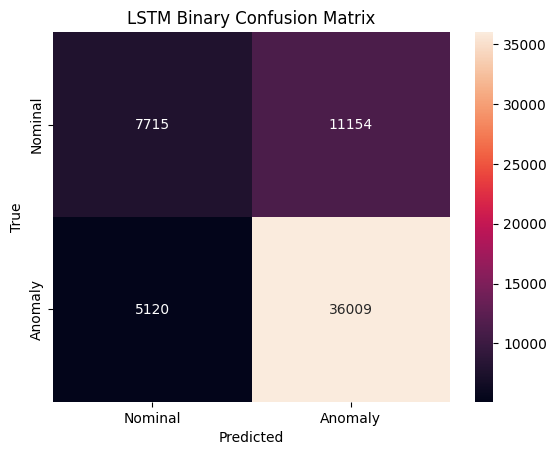

In [ ]:
cm = confusion_matrix(y_test_bin, y_pred_test)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Nominal", "Anomaly"],
            yticklabels=["Nominal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LSTM Binary Confusion Matrix")
plt.show()
